# Host and Demand Analysis

## Library import and settings

In [2]:
import pandas as pd
import seaborn as sns
from matplotlib import pyplot as plt

sns.set_style("whitegrid")
sns.set_palette("viridis")
pd.set_option("display.float_format", "{:.4f}".format)


## Load the Dataset

In [3]:
listings = pd.read_parquet("../data/processed/listings_analytics.parquet")


## Shortly Reminder

In [4]:
listings.info()


<class 'pandas.DataFrame'>
RangeIndex: 2852 entries, 0 to 2851
Data columns (total 23 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   Unnamed: 0                      2852 non-null   int64  
 1   id                              2852 non-null   int64  
 2   name                            2852 non-null   str    
 3   host_id                         2852 non-null   int64  
 4   host_name                       2849 non-null   str    
 5   neighbourhood                   2852 non-null   int64  
 6   latitude                        2852 non-null   float64
 7   longitude                       2852 non-null   float64
 8   room_type                       2852 non-null   str    
 9   price                           2537 non-null   float64
 10  minimum_nights                  2852 non-null   int64  
 11  number_of_reviews               2852 non-null   int64  
 12  last_review                     2609 non-null

In [5]:
listings.describe()


,Unnamed: 0,id,host_id,neighbourhood,latitude,longitude,price,minimum_nights,number_of_reviews,reviews_per_month,calculated_host_listings_count,availability_365,number_of_reviews_ltm,availability_ratio,review_intensity
count,2852.0000,2852.0000,2852.0000,2852.0000,2852.0000,2852.0000,2537.0000,2852.0000,2852.0000,2609.0000,2852.0000,2852.0000,2852.0000,2852.0000,2852.0000
mean,1425.5000,496846489244253760.0000,171554630.2083,28791.9947,35.5749,-82.5575,196.3839,6.2013,113.7156,2.1780,9.6466,223.5550,12.9632,0.6125,0.2270
std,823.4458,546376155207300672.0000,177553153.8102,31.0008,0.0496,0.0484,405.6750,20.5200,157.7760,1.9916,23.3005,122.2471,18.2980,0.3349,0.3159
min,0.0000,155305.0000,4134.0000,28704.0000,35.4271,-82.6699,18.0000,1.0000,0.0000,0.0200,1.0000,0.0000,0.0000,0.0000,0.0000
25%,712.7500,33522362.5000,29236831.5000,28801.0000,35.5548,-82.5918,95.0000,1.0000,11.0000,0.6900,1.0000,116.0000,1.0000,0.3178,0.0135
50%,1425.5000,53565572.0000,112295380.0000,28803.0000,35.5868,-82.5559,133.0000,2.0000,57.0000,1.6400,2.0000,263.0000,5.0000,0.7205,0.0927
75%,2138.2500,1000807194381625088.0000,247281413.7500,28806.0000,35.6058,-82.5190,211.0000,2.0000,147.0000,3.0900,4.0000,332.0000,19.0000,0.9096,0.2585
max,2851.0000,1513869641491207424.0000,712503741.0000,28806.0000,35.6581,-82.4602,9999.0000,730.0000,1473.0000,20.2900,113.0000,365.0000,255.0000,1.0000,1.0000


## Hypothesis 1: Несколько крупных владельцев задают тон объёму предложения

(0.0, 0.5431697054698457)

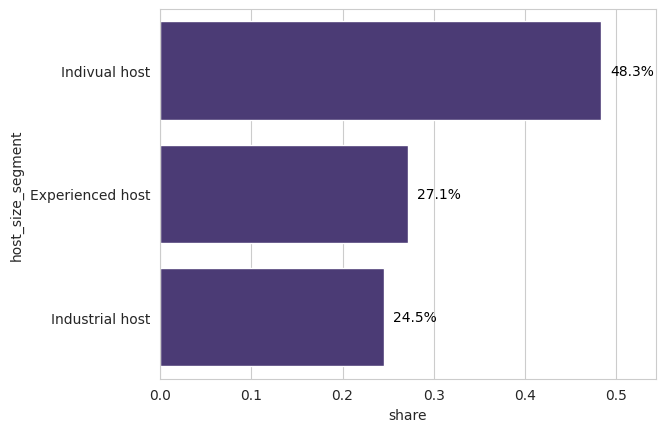

In [6]:
shares = (
    listings["host_size_segment"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .sort_values("share", ascending=False)
)

ax = sns.barplot(data=shares, x="share", y="host_size_segment")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        color="black",
    )

ax.set_xlim(0, shares["share"].max() + 0.06)


(0.0, 0.88429140580535)

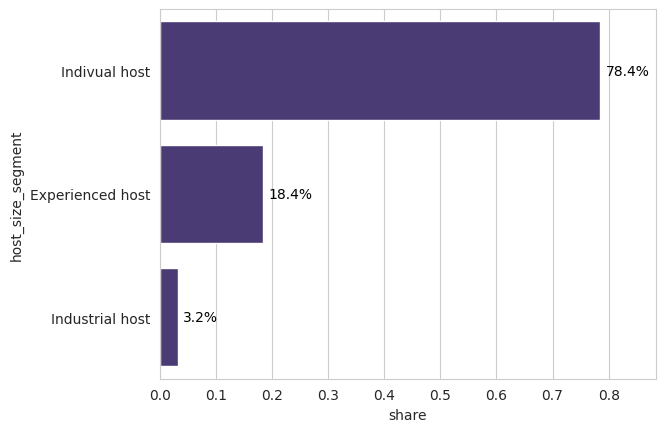

In [7]:
hosts = listings[["host_id", "host_size_segment"]].drop_duplicates()

shares_hosts = (
    hosts["host_size_segment"]
    .value_counts(normalize=True)
    .rename("share")
    .reset_index()
    .sort_values("share", ascending=False)
)

ax = sns.barplot(data=shares_hosts, x="share", y="host_size_segment")

for p in ax.patches:
    width = p.get_width()
    ax.text(
        width + 0.01,
        p.get_y() + p.get_height() / 2,
        f"{width:.1%}",
        va="center",
        ha="left",
        color="black",
    )

ax.set_xlim(0, shares_hosts["share"].max() + 0.1)


## Hypothesis 2: Чем крупнее владелец, тем большую долю в сегменте он занимает

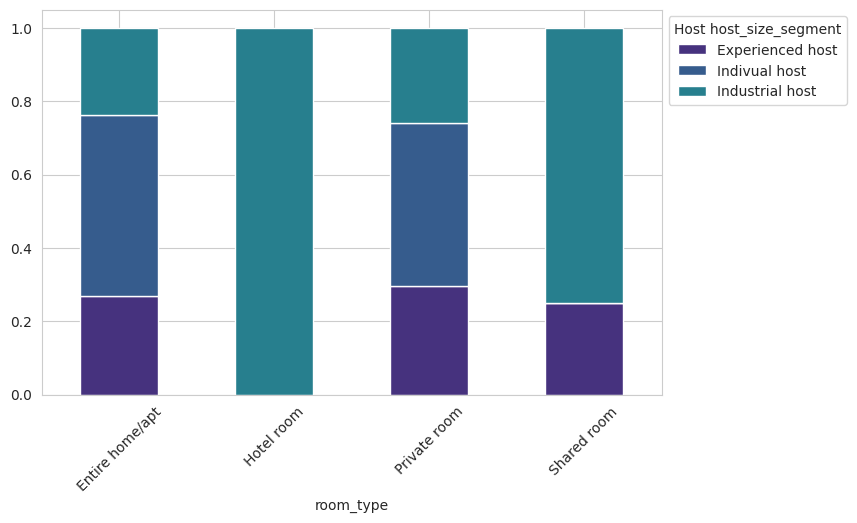

In [27]:
ct = pd.crosstab(
    index=listings["room_type"],
    columns=listings["host_size_segment"],
    normalize="index",
)

ct.plot(kind="bar", stacked=True, figsize=(8, 5))
plt.xticks(rotation=45)
plt.legend(title="Host host_size_segment", bbox_to_anchor=(1, 1))


## Hypothesis 3: Демпинг и премиальность крупных владельцев

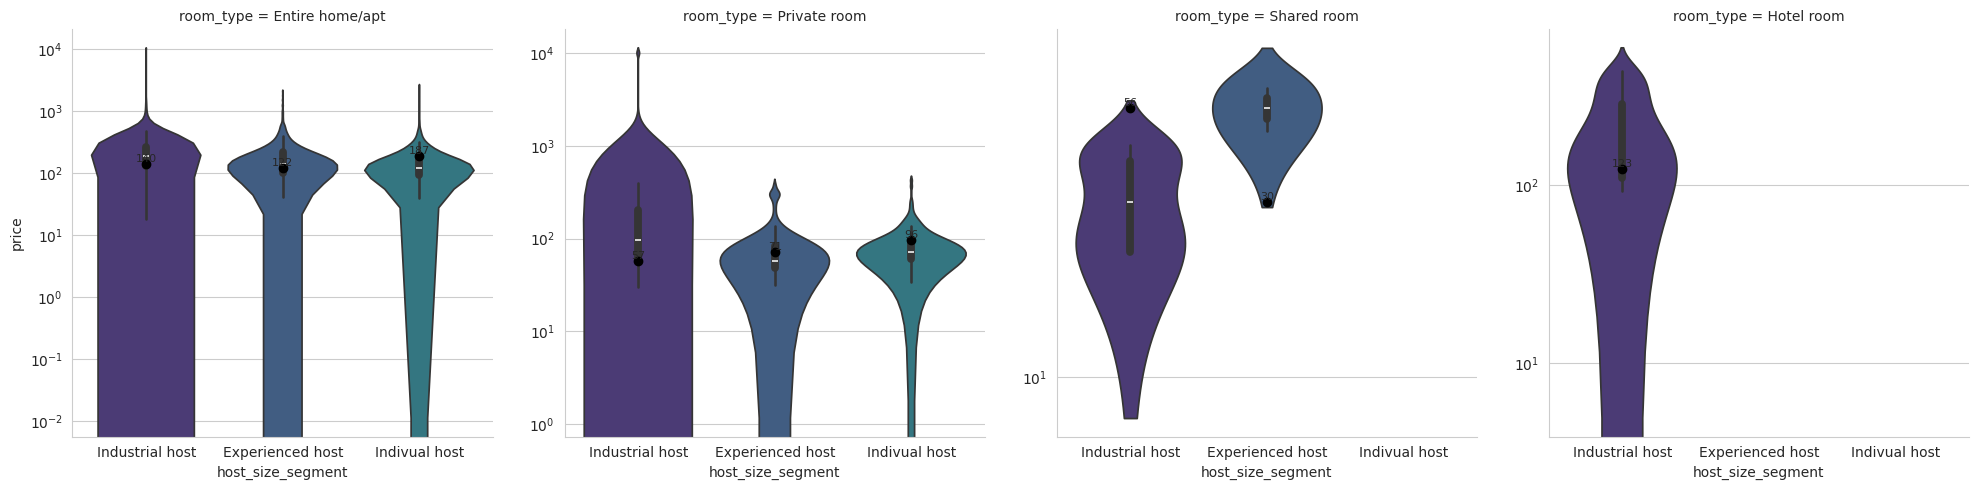

In [9]:
g = sns.catplot(
    data=listings,
    x="host_size_segment",
    y="price",
    hue="host_size_segment",
    col="room_type",
    kind="violin",
    sharey=False,
)

for ax, room in zip(g.axes.flat, listings["room_type"].unique()):
    sub = listings[listings["room_type"] == room]
    medians = sub.groupby("host_size_segment")["price"].median()

    for i, (seg, val) in enumerate(medians.items()):
        ax.scatter(i, val, color="black", zorder=3)
        ax.text(i, val, f"{val:.0f}", ha="center", va="bottom", fontsize=8)

    ax.set_yscale("log")


## Hypothesis 4: Крупные владельцы поджимают гостей длительными требованиями

<Axes: xlabel='host_size_segment', ylabel='minimum_nights'>

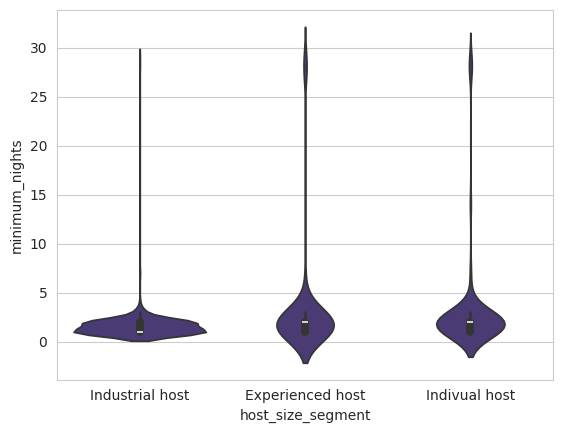

In [10]:
sns.violinplot(
    data=listings[
        listings["minimum_nights"] < listings["minimum_nights"].quantile(0.99)
    ],
    x="host_size_segment",
    y="minimum_nights",
)


## Hypothesis 5: Крупные владельцы получают больше новых отзывов, значит лучше управляют спросом

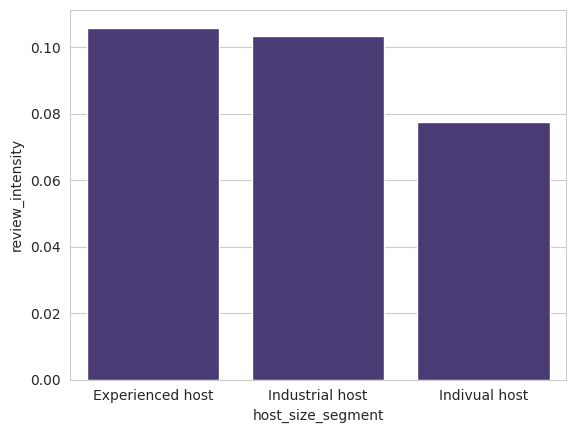

In [11]:
sns.barplot(
    data=listings.groupby("host_size_segment", as_index=False)["review_intensity"]
    .median()
    .sort_values(by="review_intensity", ascending=False),  # type: ignore
    x="host_size_segment",
    y="review_intensity",
)
plt.show()


<Axes: xlabel='number_of_reviews', ylabel='review_intensity'>

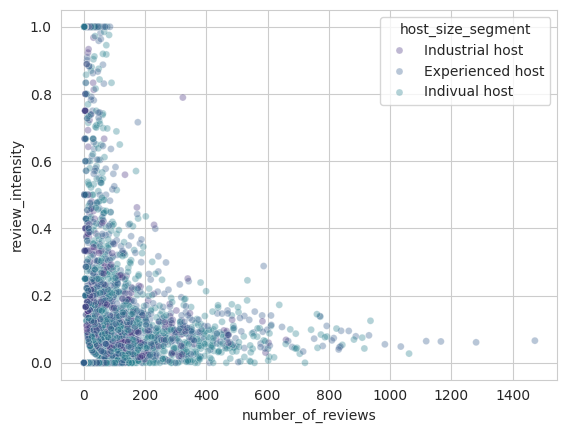

In [12]:
sns.scatterplot(
    data=listings,
    x="number_of_reviews",
    y="review_intensity",
    hue="host_size_segment",
    alpha=0.35,
    s=25,
)


## Hypothesis 6: Когда `availability_ratio` низкий, `review_intensity` высокий

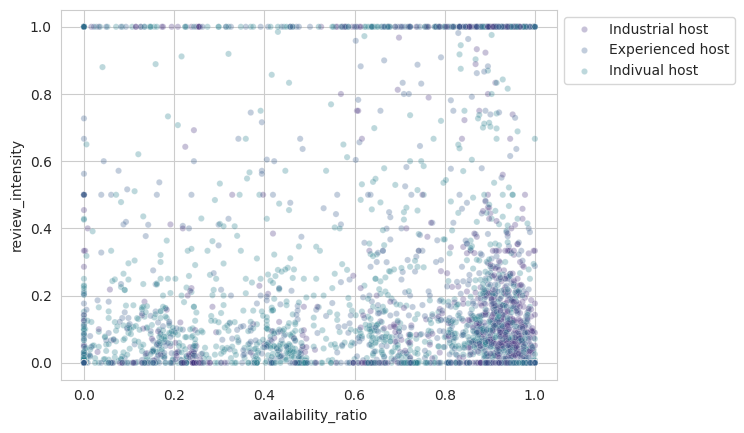

In [13]:
sns.scatterplot(
    data=listings,
    x="availability_ratio",
    y="review_intensity",
    hue="host_size_segment",
    alpha=0.3,
    s=20,
)

plt.legend(bbox_to_anchor=(1, 1))


## Hypothesis 7: Geo

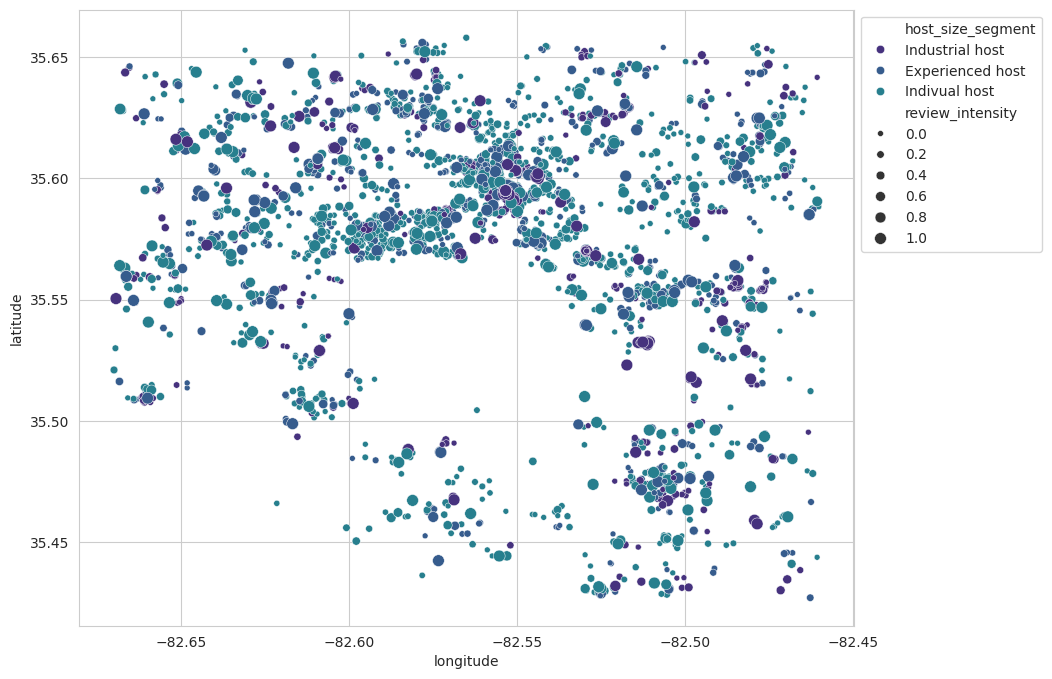

In [23]:
plt.figure(figsize=(10, 8))
sns.scatterplot(
    data=listings,
    x="longitude",
    y="latitude",
    size="review_intensity",
    hue="host_size_segment",
)
plt.legend(bbox_to_anchor=(1, 1))
